# No Linear Regression

## Regulators

## Ridge (L2) - El Ecualizador

Hace que todos los coeficientes tienden a cero, pero sin llegar a cero nunca.

Es como un ecualizador de música. Si el volumen de los graves está muy alto (coeficiente grande), Ridge lo baja un poquito, pero sigue sonando. Reparte el peso entre todas las características.

¿Cuándo usarlo?
Cuando todas tus características son relevantes y aportan información, aunque sea poca. Es ideal si tienes más columnas que filas

## Lasso (L2) - El Seleccionador de Características

Para llevar coeficientes exactamente a cero. Hace que el modelo sea esparso (sparse), es decir, se queda solo con las características más importantes y elimina el resto.

Es un "podador de árboles". Si una rama (característica) no es útil, la corta de raíz (coeficiente = 0). Así te quedas con un modelo más simple y rápido.

¿Cuándo usarlo?
Cuando crees que solo unas pocas características son realmente predictivas y el resto es ruido. Hace feature selection automático.

## ELASTICNET - El Termostato Inteligente

Para obtener lo mejor de ambos mundos:

Agrupa características correlacionadas (cualidad de Ridge).

Elimina características inútiles (cualidad de Lasso).

Es un termostato que regula la temperatura. Si pones l1_ratio=1, es Lasso puro. Si pones l1_ratio=0, es Ridge puro. Si pones 0.5, es un punto medio.

¿Cuándo usarlo?
Siempre que tengas dudas. Es el más robusto. Úsalo cuando tengas muchas características y sepas que algunas están correlacionadas entre sí (Lasso es malo eligiendo entre correlacionadas, ElasticNet las mete a todas en el grupo).

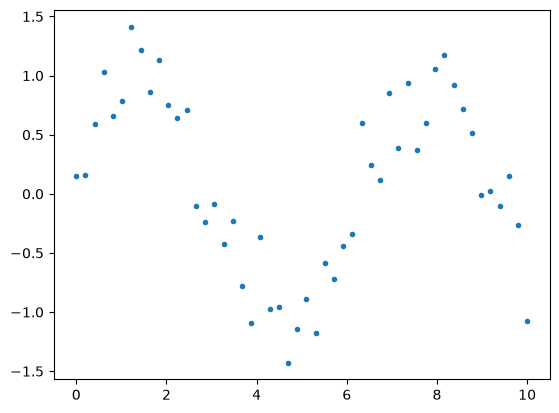

In [55]:
# See overfiting
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Generamos datos no lineales (una curva seno con ruido)
np.random.seed(42)
X = np.linspace(0, 10, 50).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

plt.plot(X, y, '.')
plt.show()


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

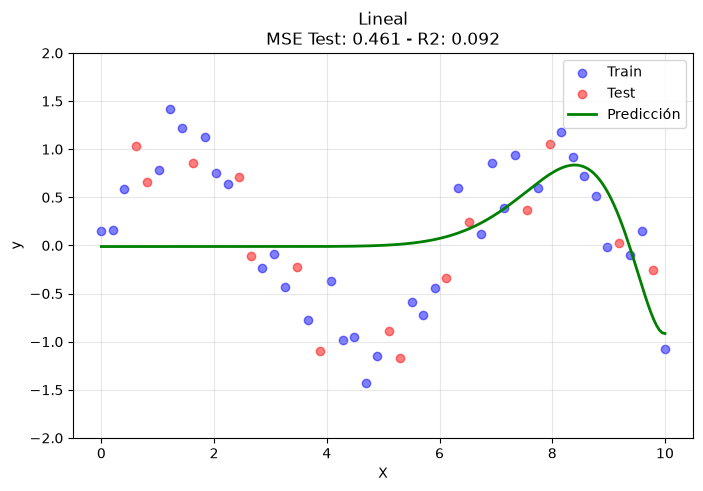

In [51]:
# Linear regression
lr_pipeline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('reg', LinearRegression())
])

lr_pipeline_model.fit(X_train, y_train)
y_pred = lr_pipeline_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot = lr_pipeline_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Predicción')
plt.title(f'Lineal\nMSE Test: {mse:.3f} - R2: {r2:.3f}')
plt.legend()
plt.ylim(-2, 2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4053197003636674e-31.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


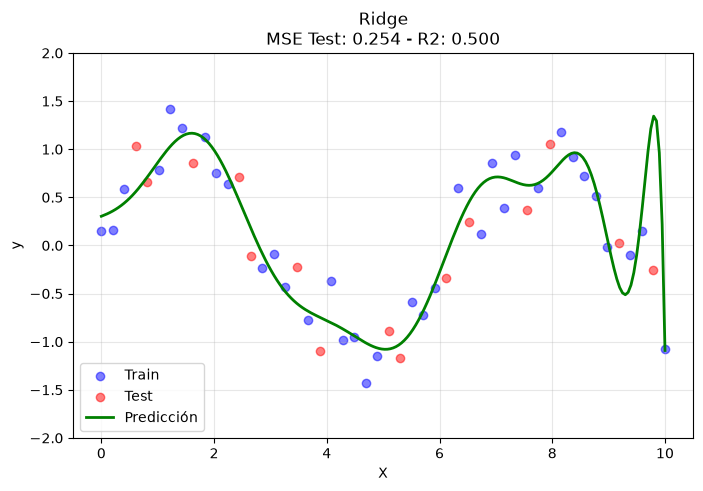

In [52]:
# Ridge 
alpha = 1
ridge_pipeline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('reg', Ridge(alpha=alpha))
])

ridge_pipeline_model.fit(X_train, y_train)
y_pred = ridge_pipeline_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot = ridge_pipeline_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Predicción')
plt.title(f'Ridge\nMSE Test: {mse:.3f} - R2: {r2:.3f}')
plt.legend()
plt.ylim(-2, 2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.879628e+00, tolerance: 2.013e-03
  model = cd_fast.enet_coordinate_descent(


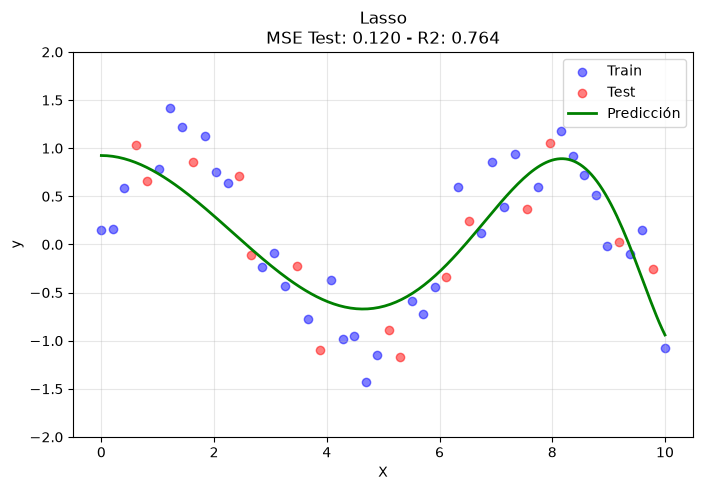

In [53]:
# Lasso 
alpha = 0.1
lasso_pipeline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('reg', Lasso(alpha=alpha))
])

lasso_pipeline_model.fit(X_train, y_train)
y_pred = lasso_pipeline_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot = lasso_pipeline_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Predicción')
plt.title(f'Lasso\nMSE Test: {mse:.3f} - R2: {r2:.3f}')
plt.legend()
plt.ylim(-2, 2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.319921e+00, tolerance: 2.013e-03
  model = cd_fast.enet_coordinate_descent(


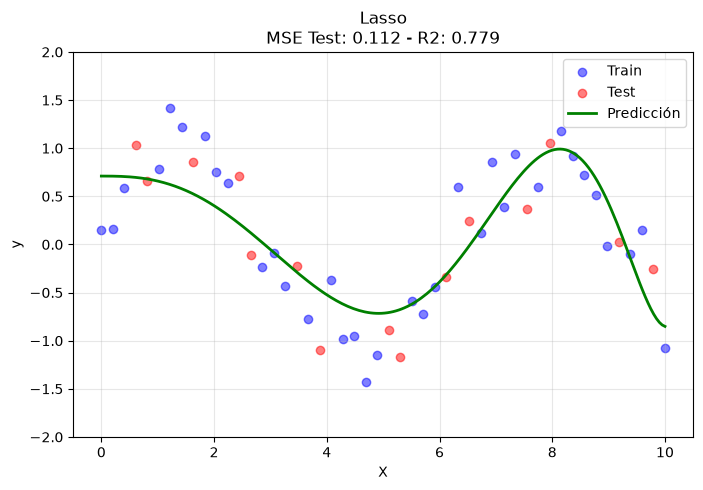

In [54]:
# ElasticNet
alpha = 0.5
l1_ratio = 0.5
lasso_pipeline_model = Pipeline([
    ('poly', PolynomialFeatures(degree=15)),
    ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000))
])

lasso_pipeline_model.fit(X_train, y_train)
y_pred = lasso_pipeline_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot = lasso_pipeline_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train')
plt.scatter(X_test, y_test, color='red', alpha=0.5, label='Test')
plt.plot(X_plot, y_plot, color='green', linewidth=2, label='Predicción')
plt.title(f'Lasso\nMSE Test: {mse:.3f} - R2: {r2:.3f}')
plt.legend()
plt.ylim(-2, 2)
plt.xlabel('X')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

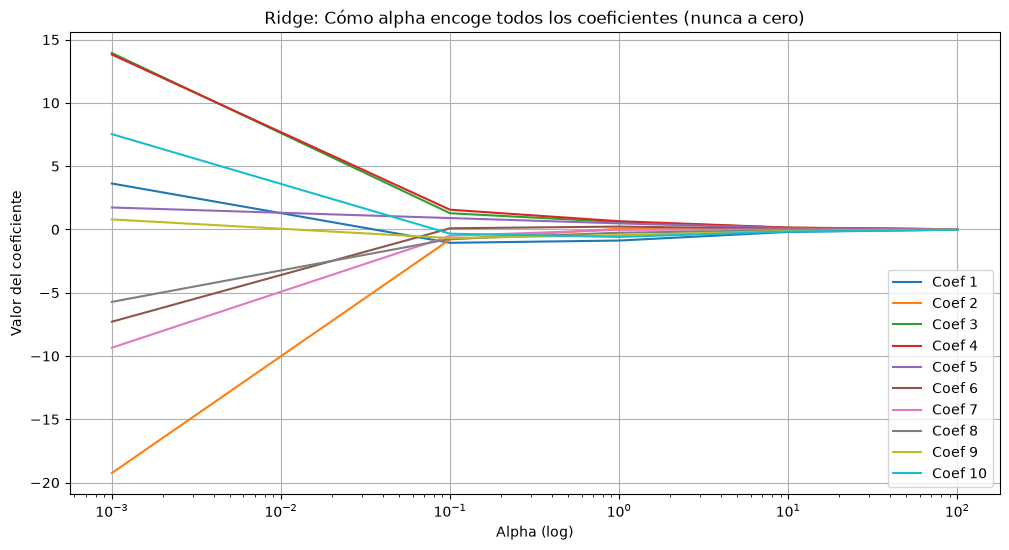

In [56]:
# Escalamos porque Lasso/Ridge son sensibles a la escala
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_train)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Probamos diferentes alphas para Ridge
alphas = [0.001, 0.1, 1, 10, 100]
coeficientes_ridge = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_scaled, y_train)
    coeficientes_ridge.append(ridge.coef_)

# Graficamos cómo se encogen los coeficientes
plt.figure(figsize=(12, 6))
for i in range(1, 11):  # omitimos el intercepto (índice 0)
    plt.plot(alphas, [c[i] for c in coeficientes_ridge], label=f'Coef {i}')
plt.xscale('log')
plt.xlabel('Alpha (log)')
plt.ylabel('Valor del coeficiente')
plt.title('Ridge: Cómo alpha encoge todos los coeficientes (nunca a cero)')
plt.legend()
plt.grid(True)
plt.show()

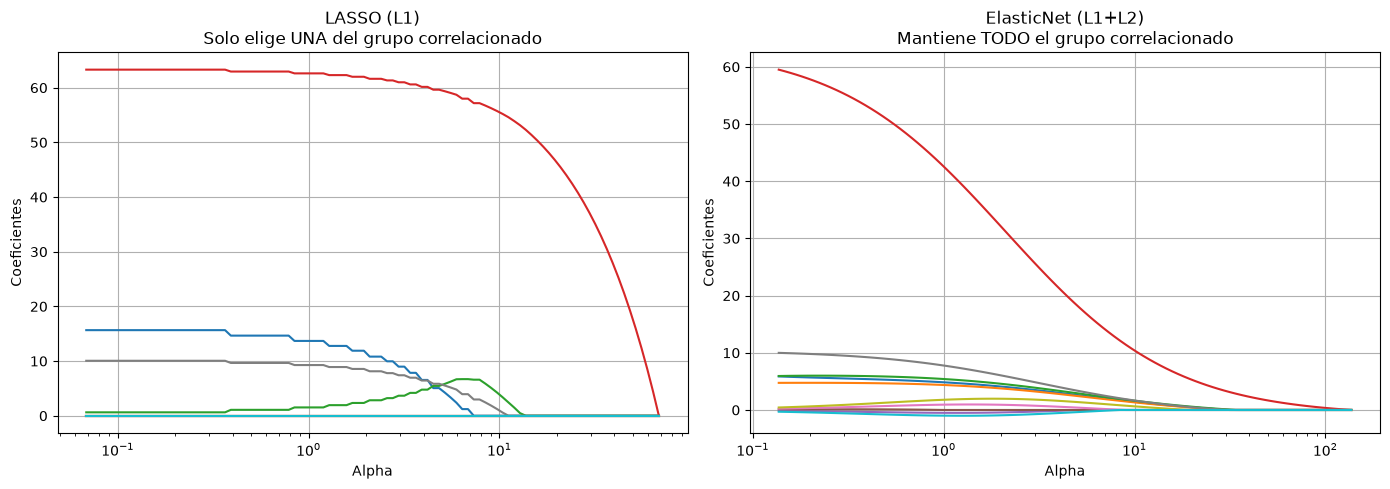

In [57]:
from sklearn.datasets import make_regression
from sklearn.linear_model import lasso_path, enet_path
import matplotlib.pyplot as plt

# Creamos datos con 10 características, pero solo 3 son relevantes, 
# y las relevantes están correlacionadas entre sí
X, y = make_regression(n_samples=100, n_features=10, n_informative=3, 
                       noise=0.5, random_state=42, coef=False)

# Añadimos correlación fuerte entre las primeras 3 características
X[:, 1] = X[:, 0] + np.random.normal(0, 0.1, 100)  # casi idéntica a la 0
X[:, 2] = X[:, 0] + np.random.normal(0, 0.1, 100)  # casi idéntica a la 0

# Calculamos caminos de regularización
alphas_lasso, coefs_lasso, _ = lasso_path(X, y, eps=1e-3)
alphas_enet, coefs_enet, _ = enet_path(X, y, eps=1e-3, l1_ratio=0.5)

# Graficamos comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Lasso
for coef in coefs_lasso:
    ax1.plot(alphas_lasso, coef)
ax1.set_xscale('log')
ax1.set_xlabel('Alpha')
ax1.set_ylabel('Coeficientes')
ax1.set_title('LASSO (L1)\nSolo elige UNA del grupo correlacionado')
ax1.grid(True)

# ElasticNet
for coef in coefs_enet:
    ax2.plot(alphas_enet, coef)
ax2.set_xscale('log')
ax2.set_xlabel('Alpha')
ax2.set_ylabel('Coeficientes')
ax2.set_title('ElasticNet (L1+L2)\nMantiene TODO el grupo correlacionado')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [58]:
from sklearn.linear_model import ElasticNetCV

# Búsqueda automática del mejor alpha y l1_ratio
elastic_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], 
                          alphas=np.logspace(-3, 1, 50), 
                          cv=5, 
                          max_iter=10000)
elastic_cv.fit(X_scaled, y_train)

print(f"Mejor alpha: {elastic_cv.alpha_}")
print(f"Mejor l1_ratio: {elastic_cv.l1_ratio_}")
print(f"Coeficientes finales: {elastic_cv.coef_}")

Mejor alpha: 0.001
Mejor l1_ratio: 0.9
Coeficientes finales: [ 0.          0.56109135 -7.32332933  5.85267898  6.16536563  0.
 -0.9703053  -4.89845607 -1.58626144 -0.          1.95064804]


C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.298869e-03, tolerance: 1.699e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:825: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.873630e-03, tolerance: 1.396e-03
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\isflo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0